# Restored Goblet/PE identities: matched energy-model experiment

Create a **separate exclusive-fate dataset** by restoring **Mucin 2** and **Glucagon** from each organoid's original organograph cell graph. Keep all organoids; record missing stain channels explicitly. Reapply the full existing exclusivity rules, including reassignments from currently named identities (especially Agr2), rather than restricting restoration to Unassigned.

Fit a **one-hop presence model without same-identity interactions**, with fixed **γ=0.5**, to mean-curvature targets standardized by measured organoid mean and SD. Reuse the reference model's exact outer/inner memberships, cleaned targets, SD floors and seeds. Only fate representation and its additional fitted coefficients change. Restore the regular-data model without retraining it.

Compare MSE on identical cells, overall, by region and by experiment. Region labels remain those of the reference run so changes in identity cannot alter evaluation membership. Plot fitted center and pair coefficients with fold dispersion, aligning the arbitrary center offset over shared identities. This notebook combines preparation, fitting and comparison because it is a single controlled experiment; all artifacts support later independent analysis.

**Interpretation:** unstained channels are zero-filled in the fixed-width feature vector and marked *unmeasured* in metadata. The model does not receive that availability flag. This is a pooled partial-label sensitivity experiment, not a statistical correction for missing identities or batch effects. Goblet/PE coefficients are supported only by the stained experiment. Observed mean and SD are used outside the predictor; it never receives measured neighboring curvature.

In [1]:
from pathlib import Path
import sys
import copy
import json
import hashlib
import shutil
import tempfile
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
PROJECT_ROOT=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'src/models/gnn.py').is_file())
if str(PROJECT_ROOT) not in sys.path:sys.path.insert(0,str(PROJECT_ROOT))
from src.data.marker_restoration import restore_marker_channels
from src.data.marker_exclusivity import exclusive_markers, EXCLUSIVITY_RULES
from src.data.neighborhood_counts import fate_identities
from src.artifacts.bundle import load_bundle, save_bundle
from src.artifacts.paths import training_run_path
from src.training.coupled_fit import graph_samples
from src.training.energy_fit import fit_energy_fixed
from src.training.progress import TrainingProgress
from src.models.size_models import seed_all
from src.analysis.metrics.conditional import conditional_region_scores


## Settings
The matching reference fixes cohort membership and target preprocessing. The explicit fitting settings below must agree with that reference. Change the output tag for a new fit; an existing restored dataset is reused only after its recorded inputs and exported contents are verified.

In [2]:
# Dataset and matching reference
REFERENCE_RUN='training_results/shape_conditioned_energy_training/no_self_secretory_gamma05_20261005_144506'  # Exact saved folds and target preprocessing.
REFERENCE_VARIANT='presence_no_self_r1'  # Regular-data comparison; no same-identity pairs.
SOURCE_DATASET='after_cleanup'  # Original GNN exports; never overwritten.
RESTORED_DATASET='after_cleanup_restored_exclusive'  # New dataset under training_data/.
RESTORE_MARKERS=['Mucin 2','Glucagon']  # Recover processed marker labels from organograph graphs.

# Execution and output
RUN_TRAINING=True  # Fit all five matched folds; False loads an existing completed run.
RESUME_RUN='training_results/restored_fate_energy_comparison/restored_mucin_glucagon_gamma05_20261005_154027'  # Completed run; None creates a fresh run. Existing folds are reused.
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'  # Same fixed-energy solver on CPU or CUDA.
SHOW_PROGRESS=True  # Display fold-level fitting progress.
SETTINGS=dict(
    # Run identity and target definition
    tag='restored_mucin_glucagon_gamma05',  # Purpose label in training_results/.
    target_mode='standardized',  # Measured mean+SD targets, identical to the reference.
    gamma=.5,  # Fixed accommodation, with no N dependence.
    radius=1,  # One-hop literal presence; all directed pairs except A→A.

    # Reproducibility and shrinkage
    split_seed=42,  # Validate against reference; saved membership is loaded, never redrawn.
    inner_seed=42,  # Same inner regularization-selection split.
    inner_fraction=.2,  # Training-only holdout fraction.
    center_ridge=.0001,  # Center penalty, as in the reference.
    pair_ridge_grid=[.0001,.001],  # Same grid; select independently using inner training validation.
    min_pair_organoids=20,  # Flag weak support without silently deleting pairs.
    solver_rtol=1e-11,  # CUDA linear-system tolerance.
    blas_threads=4,  # Bound CPU/torch thread use.
)

# Evaluation: identical cells and weights in both models
REGIONS=['total','crypt_with_LGR5','crypt_without_LGR5','neck','villus','spherical_or_no_detected_crypt']  # Reference anatomical labels.
MSE_METRICS=['mse','standardized_mse']  # Physical curvature and SD-normalized errors.
NOTEBOOK_NAME='restored_fate_energy_comparison'  # Training output namespace.
SOURCE_DIR=PROJECT_ROOT/'training_data'/SOURCE_DATASET
DATASET_DIR=PROJECT_ROOT/'training_data'/RESTORED_DATASET
REFERENCE_DIR=PROJECT_ROOT/REFERENCE_RUN
RUN_DIR=Path(RESUME_RUN) if RESUME_RUN else training_run_path(PROJECT_ROOT,NOTEBOOK_NAME,SETTINGS['tag'])


## Restore and verify the dataset
Load cell graphs with organograph and map original cell IDs into GNN node order. Preserve every target, edge and non-feature NPZ array. Record channel availability and identity transitions. The export is staged and then renamed, so an interrupted export does not leave a completed-looking dataset. On rerun, source and output hashes are checked.

In [3]:
def digest(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def labels(x,names):
    return np.array(list(names)+['Unassigned'])[fate_identities(x)]

if DATASET_DIR.resolve()==SOURCE_DIR.resolve():raise ValueError('Use a separate output dataset.')
source_paths=sorted(SOURCE_DIR.glob('organoid_*.npz'))
if not source_paths:raise ValueError('No source graphs.')
source_hashes={p.name:digest(p) for p in SOURCE_DIR.iterdir() if p.is_file()}
original_hashes={}
for p in source_paths:
    meta=json.loads(p.with_name(p.stem+'_aux.json').read_text())
    original_hashes[str(Path(meta['graph_path']).resolve())]=digest(meta['graph_path'])
export_config=dict(source_dataset=SOURCE_DATASET,markers=RESTORE_MARKERS,exclusive_rules=EXCLUSIVITY_RULES,
    marker_field='markers_bin',missing_channels='zero-filled, availability retained in metadata',
    source_hashes=source_hashes,original_graph_hashes=original_hashes,
    code_hashes={name:digest(PROJECT_ROOT/name) for name in ['src/data/marker_restoration.py','src/data/marker_exclusivity.py']})
if DATASET_DIR.exists():
    manifest=json.loads((DATASET_DIR/'restoration_manifest.json').read_text())
    if manifest['config']!=export_config:raise ValueError('Source data/rules changed; choose a new dataset directory.')
    for name,expected in manifest['export_hashes'].items():
        if digest(DATASET_DIR/name)!=expected:raise ValueError(f'Restored dataset changed: {name}')
else:
    staging=Path(tempfile.mkdtemp(prefix=f'.{RESTORED_DATASET}-',dir=DATASET_DIR.parent))
    rows=[];transitions=Counter()
    try:
        for path in source_paths:
            oid=path.stem;meta=json.loads(path.with_name(oid+'_aux.json').read_text())
            names=json.loads(path.with_name(oid+'_markers.json').read_text())
            with np.load(path,allow_pickle=False) as z:arrays={name:z[name].copy() for name in z.files}
            regular=exclusive_markers(arrays['x'],names)
            restored,new_names,availability=restore_marker_channels(arrays['x'],names,meta,RESTORE_MARKERS,edges=arrays['edges'])
            before=labels(regular,names);after=labels(restored,new_names)
            for a,b in zip(before,after):
                if a!=b:transitions[(str(meta['dataset']),a,b)]+=1
            arrays['x']=restored
            np.savez_compressed(staging/path.name,**arrays)
            meta['marker_measurement_available']={name:True for name in names}|availability
            meta['marker_restoration']=dict(source_dataset=SOURCE_DATASET,restored_markers=RESTORE_MARKERS,exclusive=True)
            (staging/(oid+'_aux.json')).write_text(json.dumps(meta))
            (staging/(oid+'_markers.json')).write_text(json.dumps(new_names,indent=2))
            rows.append(dict(organoid_str=oid,dataset=str(meta['dataset']),timepoint=meta['timepoint'],cells=len(restored),
                unassigned_before=int((before=='Unassigned').sum()),unassigned_after=int((after=='Unassigned').sum()),
                reassigned_known=int(((before!=after)&(before!='Unassigned')).sum()),
                **{name+'_measured':available for name,available in availability.items()},
                **{name+'_cells':int((after==name).sum()) for name in RESTORE_MARKERS}))
        for name in ['organoid_blacklist.json','marker_harmonization.json','failures.log']:
            if (SOURCE_DIR/name).exists():shutil.copy2(SOURCE_DIR/name,staging/name)
        original_manifest=pd.read_csv(SOURCE_DIR/'manifest.csv')
        original_manifest['n_feature_markers']=len(new_names)
        original_manifest['exclusive_markers']=True
        original_manifest['out_path']=[str(DATASET_DIR/f'organoid_{uid}.npz') for uid in original_manifest.label_uid]
        original_manifest.to_csv(staging/'manifest.csv',index=False)
        pd.DataFrame(rows).to_csv(staging/'restoration_summary.csv',index=False)
        pd.DataFrame([dict(dataset=d,before=a,after=b,cells=c) for (d,a,b),c in transitions.items()]).to_csv(staging/'identity_transitions.csv',index=False)
        exports={p.name:digest(p) for p in staging.iterdir() if p.is_file()}
        (staging/'restoration_manifest.json').write_text(json.dumps(dict(config=export_config,export_hashes=exports),indent=2))
        staging.rename(DATASET_DIR)
    except BaseException:
        shutil.rmtree(staging);raise
# Independently check serialization and exact preservation of every non-feature array.
regular_x={};restored_x={};metadata={}
for path in source_paths:
    oid=path.stem;names=json.loads(path.with_name(oid+'_markers.json').read_text())
    with np.load(path,allow_pickle=False) as old,np.load(DATASET_DIR/path.name,allow_pickle=False) as new:
        if set(old.files)!=set(new.files):raise ValueError('NPZ fields changed.')
        for field in old.files:
            if field!='x':np.testing.assert_array_equal(old[field],new[field])
        regular_x[oid]=exclusive_markers(old['x'],names)
        restored_x[oid]=new['x'].copy()
        if np.any(new['x'].sum(1)>1):raise ValueError('Nonexclusive restored features.')
    metadata[oid]=json.loads((DATASET_DIR/(oid+'_aux.json')).read_text())
marker_names=json.loads((DATASET_DIR/(source_paths[0].stem+'_markers.json')).read_text())
identity_names=marker_names+['Unassigned'];common_names=names+['Unassigned']
restoration=pd.read_csv(DATASET_DIR/'restoration_summary.csv',dtype={'dataset':str})
display(restoration.groupby('dataset').agg(organoids=('organoid_str','size'),cells=('cells','sum'),
    mucin_cells=('Mucin 2_cells','sum'),glucagon_cells=('Glucagon_cells','sum'),reassigned_known=('reassigned_known','sum')))
print('Verified separate dataset:',DATASET_DIR)


,organoids,cells,mucin_cells,glucagon_cells,reassigned_known
dataset,,,,,
20250929,1222,435088,6545,175,6149
20251201,278,120543,0,0,0


Verified separate dataset: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data/after_cleanup_restored_exclusive


## Match the saved cohort, folds and preprocessing
Load exact reference memberships and previously cleaned physical targets. Replace only node features. Copy measured moments and inner-training memberships unchanged; retain the reference anatomical labels for fair regional comparisons. Both experiments remain in every relevant fold; no newly restored marker is inferred in the unstained experiment.

In [4]:
reference_settings=json.loads((REFERENCE_DIR/'settings.json').read_text())
membership=json.loads((REFERENCE_DIR/'splits.json').read_text())
reference_records=pd.read_json(REFERENCE_DIR/'models.json')
reference_records=reference_records[(reference_records.variant==REFERENCE_VARIANT)&(reference_records.target_mode==SETTINGS['target_mode'])&np.isclose(reference_records.gamma,SETTINGS['gamma'])]
if len(reference_records)!=len(membership) or reference_records.fold.duplicated().any():raise ValueError('Expected one matching reference per fold.')
for key in ['split_seed','inner_seed','inner_fraction','center_ridge','pair_ridge_grid','min_pair_organoids','solver_rtol','gamma']:
    if SETTINGS[key]!=reference_settings[key]:raise ValueError(f'Unmatched reference setting: {key}')
if SETTINGS['radius']!=1 or SETTINGS['target_mode']!='standardized':raise ValueError('This comparison requires one-hop presence and mean+SD normalization.')
config=dict(reference_settings,**{'tag':SETTINGS['tag'],'dataset':RESTORED_DATASET,'target_modes':[SETTINGS['target_mode']],
    'models':[dict(name='restored_no_self_r1',family='energy',radius=1,exclude_same_identity=True)],
    'reference_run':str(REFERENCE_DIR),'reference_variant':REFERENCE_VARIANT,'restored_markers':RESTORE_MARKERS,
    'restoration_manifest_sha256':digest(DATASET_DIR/'restoration_manifest.json'),'device':DEVICE})
torch.set_num_threads(SETTINGS['blas_threads']);seed_all(SETTINGS['inner_seed'])
if not RUN_TRAINING and not (RUN_DIR/'complete.json').exists():raise ValueError('Select a completed RESUME_RUN or enable fitting.')
if RUN_DIR.exists():
    if json.loads((RUN_DIR/'settings.json').read_text())!=config:raise ValueError('Resume settings differ.')
else:
    RUN_DIR.mkdir(parents=True);(RUN_DIR/'settings.json').write_text(json.dumps(config,indent=2))
    for name in ['splits.json','cohort.csv','regions.csv.gz','observed_moments.csv','exclusivity_rules.json']:
        shutil.copy2(REFERENCE_DIR/name,RUN_DIR/name)
    saved=load_bundle(REFERENCE_DIR/'cohort')
    for oid,g in saved['raw_graphs'].items():
        np.testing.assert_array_equal(g.x.numpy(),regular_x[oid])
        g.x=torch.as_tensor(restored_x[oid],dtype=g.x.dtype);g.meta=metadata[oid]
    saved['all_marker_names']=marker_names;saved['settings']=config
    save_bundle(RUN_DIR/'cohort',saved,splits=membership,provenance=dict(reference_run=str(REFERENCE_DIR),only_features_changed=True))
for folder in ['history','predictions','analysis']:(RUN_DIR/folder).mkdir(exist_ok=True)
for split in membership:
    path=RUN_DIR/f'inputs/fold_{split["fold"]}_mean'
    if path.exists():continue
    prepared=load_bundle(REFERENCE_DIR/f'inputs/fold_{split["fold"]}_mean')
    for role,graphs in prepared['physical_groups'].items():
        expected=split[{'train':'train','val':'validation','spherical':'spherical_validation'}[role]]
        if [str(g.organoid_str) for g in graphs]!=expected:raise ValueError('Reference membership mismatch.')
        for g in graphs:
            oid=str(g.organoid_str);np.testing.assert_array_equal(g.x.numpy(),regular_x[oid])
            g.x=torch.as_tensor(restored_x[oid],dtype=g.x.dtype);g.meta=metadata[oid]
    prepared['marker_names']=marker_names
    save_bundle(path,prepared,splits=split,provenance=dict(reference_run=str(REFERENCE_DIR),targets_moments_and_memberships_unchanged=True))
cohort=pd.read_csv(RUN_DIR/'cohort.csv');cohort['dataset']=cohort.organoid_str.map(lambda oid:str(metadata[oid]['dataset']))
cohort.to_csv(RUN_DIR/'cohort.csv',index=False)
display(cohort.groupby(['dataset','cohort']).agg(organoids=('organoid_str','size'),cells=('N','sum')))
print('Matching folds:',len(membership),'| output:',RUN_DIR,'| device:',DEVICE)


organoids   cells
dataset  cohort                      
20250929 ordinary         675  316161
         spherical        242   57118
20251201 ordinary         194  103581
         spherical         82   13653

Matching folds: 5 | output: training_results/restored_fate_energy_comparison/restored_mucin_glucagon_gamma05_20261005_154027 | device: cuda


## Fit all folds and save target-free predictions
The 10 identities yield 90 allowed directed pair terms plus 10 center preferences. Accommodation, literal presence activation and all other equations are unchanged. Select the pair penalty only on the identical inner split, then refit each outer training fold. Validation targets are removed from model inputs before predicting; measured moments enter only physical reconstruction.

In [5]:
records=json.loads((RUN_DIR/'models.json').read_text()) if (RUN_DIR/'models.json').exists() else []
with TrainingProgress(len(membership),show=SHOW_PROGRESS,log_path=RUN_DIR/'energy_progress.csv') as progress:
    for split in membership:
        fold=split['fold'];prepared=load_bundle(RUN_DIR/f'inputs/fold_{fold}_mean')
        train=[]
        for g in prepared['physical_groups']['train']:
            h=g.clone();m=prepared['moments'][str(g.organoid_str)];h.y=(h.y-m.mean)/m.scale;train.append(h)
        key=f'standardized_restored_no_self_r1_g00_f{fold}'
        record=dict(key=key,name='standardized_restored_no_self_r1',variant='restored_no_self_r1',target_mode='standardized',
            gamma=SETTINGS['gamma'],fold=fold,depth=1,family='energy',bundle=f'models/{key}',input_bundle=f'inputs/fold_{fold}_mean',
            output_projection='graph_mean',target_indices=[1])
        with progress.task(model='Restored fates: no-self presence, gamma=0.5',depth=1,fold=fold):
            if (RUN_DIR/record['bundle']).exists():
                payload=load_bundle(RUN_DIR/record['bundle']);model=payload['model'];metrics=payload['metrics']
            else:
                if not RUN_TRAINING:raise ValueError('Missing saved fold.')
                pairs=[(a,b) for a in range(len(identity_names)) for b in range(len(identity_names)) if a!=b]
                spec=dict(n_markers=len(marker_names),pairs=True,activation='presence',interaction='pooled',center_response=False,
                    exposure_kind='fractions',pair_constraints='direct',source_indices=list(range(len(identity_names))),
                    recipient_indices=list(range(len(identity_names))),pair_indices=pairs,interaction_radius=1,
                    min_pair_organoids=SETTINGS['min_pair_organoids'],zero_mean_output=True)
                penalties=[dict(ridge=SETTINGS['center_ridge'],pair_ridge=p,slope_ridge=0.,lambda_ridge=0.,alpha_ridge=0.) for p in SETTINGS['pair_ridge_grid']]
                model,metrics,trials=fit_energy_fixed(graph_samples(train,2),model_settings=spec,strength=SETTINGS['gamma'],penalties=penalties,
                    seed=SETTINGS['inner_seed'],inner_fraction=SETTINGS['inner_fraction'],device=DEVICE,
                    solver_rtol=SETTINGS['solver_rtol'],blas_threads=SETTINGS['blas_threads'])
                save_bundle(RUN_DIR/record['bundle'],dict(model=model,metrics=metrics,record=record),splits=split,
                    provenance=dict(reference_run=str(REFERENCE_DIR),restored_markers=RESTORE_MARKERS))
                trials.to_json(RUN_DIR/'history'/f'{key}.json',orient='records',indent=2)
            assert metrics['fit_organoids']==split['train']
            assert metrics['inner_train']==prepared['inner_train'] and metrics['inner_validation']==prepared['inner_validation']
            np.testing.assert_array_equal(np.diag(model.coefficients([1])['amplitude'][0]),0)
            record['inner_mse']=metrics['best']['inner_mse'];records=[r for r in records if r['key']!=key]+[record]
            (RUN_DIR/'models.json').write_text(json.dumps(records,indent=2))
            for role in ['val','spherical']:
                graphs=prepared['physical_groups'][role];samples=graph_samples(graphs,2)
                for sample in samples:sample.pop('y')
                pred=model.predict_samples(samples,device=DEVICE,rtol=SETTINGS['solver_rtol'])
                ids=[];offsets=[0];truth=[];physical=[];truth_z=[];prediction_z=[]
                for g,z in zip(graphs,pred):
                    oid=str(g.organoid_str);m=prepared['moments'][oid]
                    if abs(np.mean(z))>1e-7 or not np.isfinite(z).all():raise ValueError('Invalid graph-centered prediction.')
                    ids.append(oid);offsets.append(offsets[-1]+len(z));truth.append(g.y.numpy());physical.append(m.mean+m.scale*z)
                    truth_z.append((g.y.numpy()-m.mean)/m.scale);prediction_z.append(z)
                np.savez_compressed(RUN_DIR/'predictions'/f'{key}_{role}.npz',organoid_ids=ids,offsets=offsets,truth=np.concatenate(truth),
                    prediction=np.concatenate(physical),truth_z=np.concatenate(truth_z),prediction_z=np.concatenate(prediction_z))
print('Saved',len(records),'fitted folds.')


/home/fmoller/Projects/LearningOrganoids/GraphNN/src/models/energy_ops.py:121: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  self.laplacian = torch.sparse_csr_tensor(self.crow,self.col,self.lap_values,size=lap.shape,device=self.device)


Saved 5 fitted folds.


## Matched errors and coefficient extraction
Score both models on the same targets, organoids and anatomical labels. The baseline predicts each organoid's measured mean. Each organoid receives equal weight within a fold; fold means then receive equal weight. Retain experiment-specific scores because the second panel has no restored measurements.

Center coefficients have an arbitrary common offset. For comparisons, subtract the mean over the **same eight shared identities** in each model/fold. Raw coefficients are also exported. Pair amplitudes require no common-offset adjustment, but changing identity definitions can still redistribute them. Missing baseline coefficients for Mucin 2/Glucagon are left missing, not set to zero.

In [5]:
records=json.loads((RUN_DIR/'models.json').read_text())
OUTPUT_DIR=RUN_DIR/'analysis';regions=pd.read_csv(RUN_DIR/'regions.csv.gz',low_memory=False)
region_by_id={str(oid):d.sort_values('node').region.to_numpy() for oid,d in regions.groupby('organoid_str')}
metric_rows=[];coefficient_rows=[];checks=[]
for split in membership:
    fold=split['fold'];prepared=load_bundle(RUN_DIR/f'inputs/fold_{fold}_mean')
    old=reference_records[reference_records.fold==fold].iloc[0].to_dict();new=next(r for r in records if r['fold']==fold)
    for label,base,rec,names_for_model in [('Regular',REFERENCE_DIR,old,common_names),('Restored',RUN_DIR,new,identity_names)]:
        payload=load_bundle(base/rec['bundle']);model=payload['model']
        assert payload['metrics']['fit_organoids']==split['train']
        assert payload['metrics']['inner_train']==prepared['inner_train'] and payload['metrics']['inner_validation']==prepared['inner_validation']
        coef=model.coefficients([1]);center=coef['center'][0];offset=np.mean([center[names_for_model.index(a)] for a in common_names])
        for a,A in enumerate(names_for_model):
            coefficient_rows.append(dict(model=label,fold=fold,family='center',recipient=A,source='',value=float(center[a]-offset),raw_value=float(center[a])))
            for b,B in enumerate(names_for_model):
                if a==b:continue
                coefficient_rows.append(dict(model=label,fold=fold,family='interaction',recipient=A,source=B,
                    value=float(coef['amplitude'][0,a,b]),raw_value=float(coef['amplitude'][0,a,b]),support=int(model.pair_support[a,b])))
        for role in ['val','spherical']:
            graphs=prepared['physical_groups'][role]
            with np.load(base/'predictions'/f'{rec["key"]}_{role}.npz',allow_pickle=False) as archive:
                assert list(archive['organoid_ids'])==[str(g.organoid_str) for g in graphs]
                np.testing.assert_array_equal(archive['truth'],np.concatenate([g.y.numpy() for g in graphs]))
                frame=conditional_region_scores(archive,region_by_id,prepared['moments'],cohort=role,include_mean_reference=label=='Regular')
                frame['model']=label;frame.loc[frame.is_reference,'model']='Measured mean';frame['fold']=fold
                frame['dataset']=frame.organoid_str.map(lambda oid:str(metadata[oid]['dataset']));metric_rows.append(frame)
                g=graphs[0].clone()
                if label=='Regular':g.x=torch.as_tensor(regular_x[str(g.organoid_str)],dtype=g.x.dtype)
                sample=graph_samples([g],2)[0];sample.pop('y');z=model.predict_sample(sample)
                m=prepared['moments'][str(g.organoid_str)];error=float(np.max(abs(m.mean+m.scale*z-archive['prediction'][:len(z)])))
                if error>2e-6:raise ValueError('Restored checkpoint disagrees with archived predictions.')
                checks.append(dict(model=label,fold=fold,cohort=role,max_difference=error))
metrics=pd.concat(metric_rows,ignore_index=True);coefficients=pd.DataFrame(coefficient_rows)
fold_scores=metrics.groupby(['model','region','fold'])[['mse','standardized_mse']].mean().reset_index()
summary=fold_scores.groupby(['model','region'])[['mse','standardized_mse']].agg(['mean','sem'])
experiment_scores=metrics[metrics.region=='total'].groupby(['dataset','model','fold'])[['mse','standardized_mse']].mean().reset_index()
for name,table in [('organoid_scores',metrics),('fold_scores',fold_scores),('experiment_fold_scores',experiment_scores),('coefficients',coefficients),('restoration_checks',pd.DataFrame(checks))]:
    table.to_csv(OUTPUT_DIR/f'{name}.csv',index=False)
summary.to_csv(OUTPUT_DIR/'summary.csv')
colors={'Regular':'tab:blue','Restored':'tab:orange','Measured mean':'gray'}
order=['Regular','Restored','Measured mean']
def save_figure(fig,name):
    fig.savefig(OUTPUT_DIR/f'{name}.png',dpi=160,bbox_inches='tight');plt.show()
def errors_panel(ax,table,metric,title):
    for j,label in enumerate(order):
        values=table[table.model==label][metric]
        ax.scatter(np.full(len(values),j),values,color=colors[label],s=16,alpha=.35)
        ax.errorbar(j,values.mean(),yerr=values.sem(),fmt='D',color=colors[label],capsize=3)
    ax.set_xticks(range(3),order,rotation=25,ha='right');ax.set_title(title)
    ax.set_ylabel('Physical MSE' if metric=='mse' else 'Standardized MSE')


## Validation MSE: overall, anatomy and experiment
Thin fold points and mean ± fold SEM show the variation across fitted models. Spherical-like organoids are evaluated only, and contribute to the combined spherical/no-crypt category. The experiment panels use ordinary validation only. The baseline and evaluation cells are identical in both models.

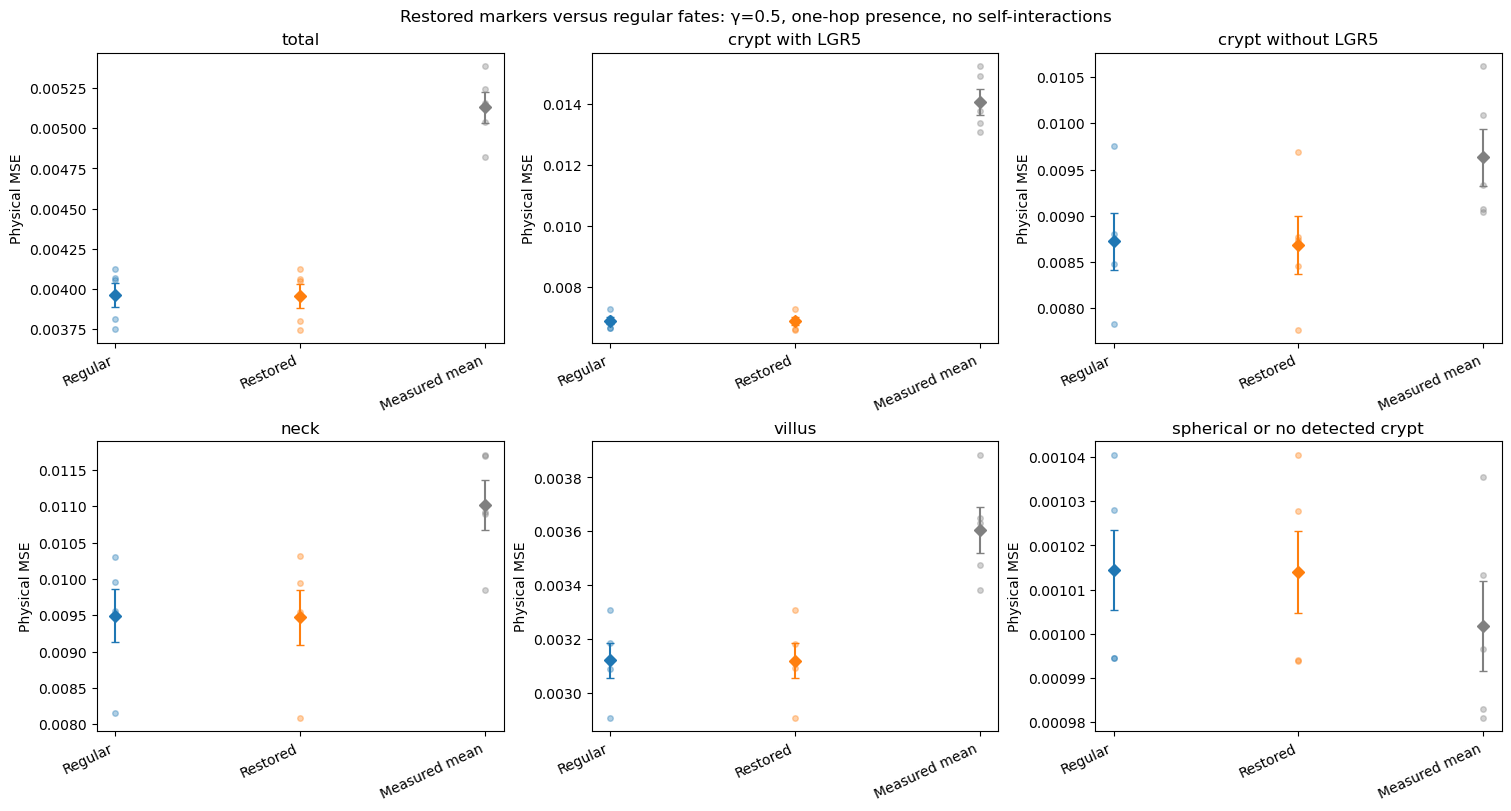

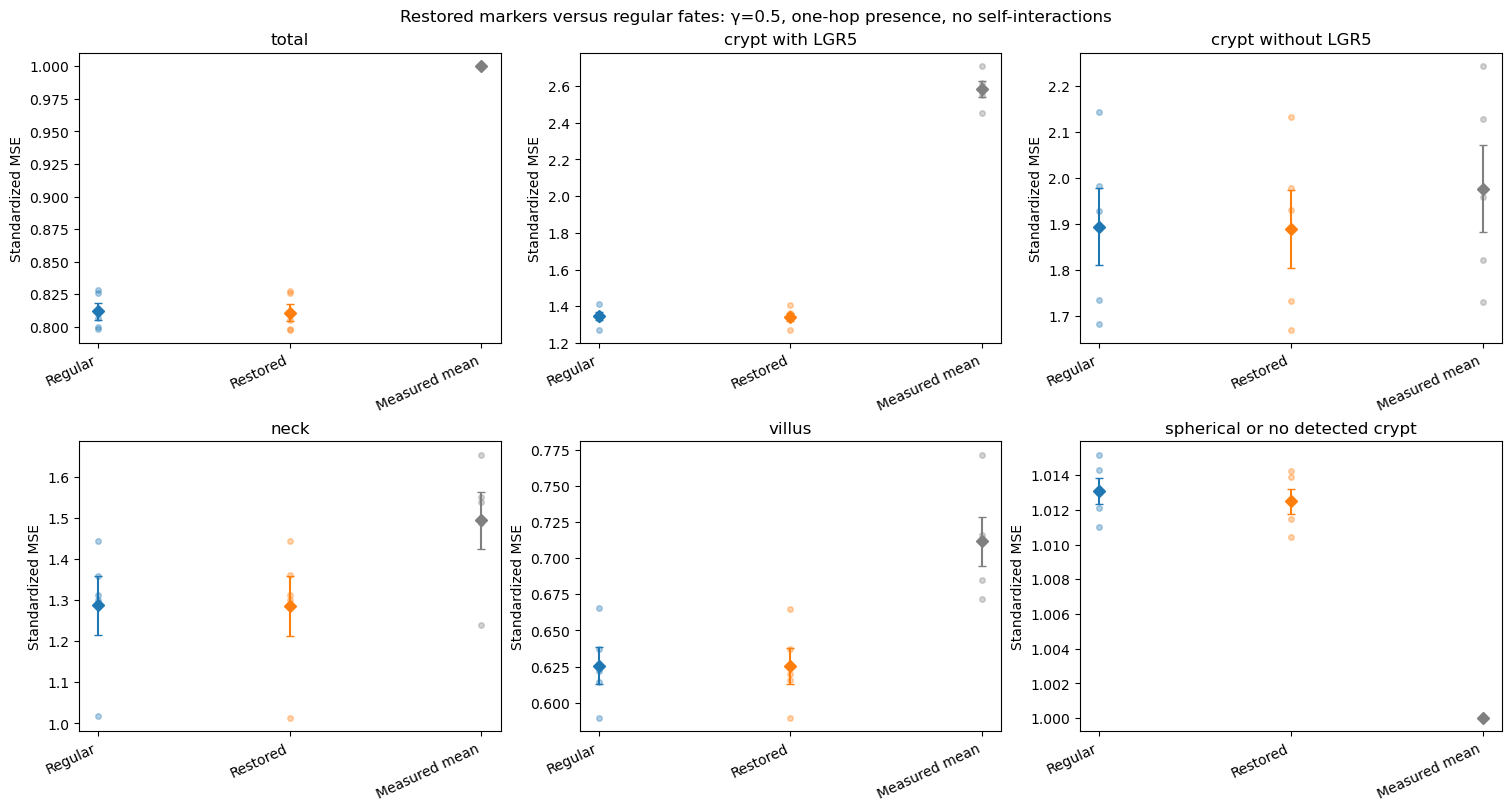

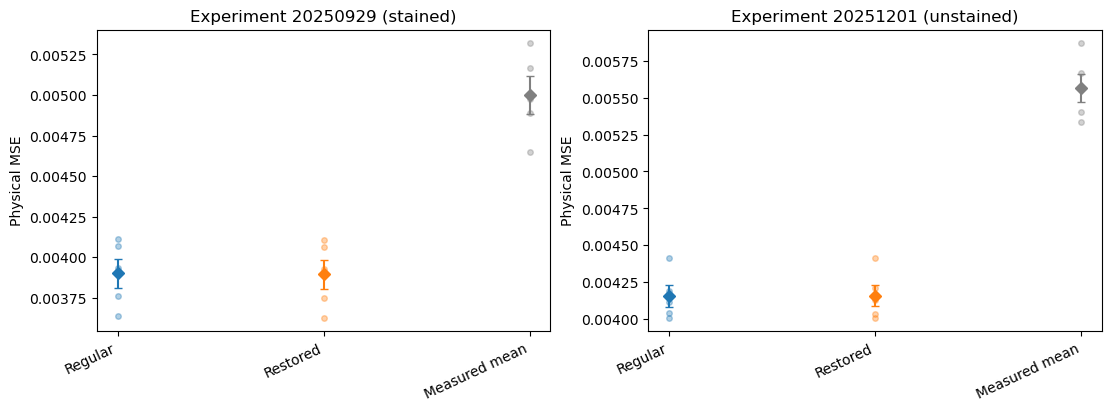

In [6]:
for metric in MSE_METRICS:
    fig,axes=plt.subplots(2,3,figsize=(15,8),layout='constrained')
    for ax,region in zip(axes.flat,REGIONS):errors_panel(ax,fold_scores[fold_scores.region==region],metric,region.replace('_',' '))
    fig.suptitle('Restored markers versus regular fates: γ=0.5, one-hop presence, no self-interactions')
    save_figure(fig,f'01_regions_{metric}')
fig,axes=plt.subplots(1,2,figsize=(11,4),layout='constrained')
for ax,(dataset,table) in zip(axes,experiment_scores.groupby('dataset')):
    errors_panel(ax,table,'mse',f'Experiment {dataset}'+(' (stained)' if restoration[restoration.dataset==dataset]['Mucin 2_measured'].all() else ' (unstained)'))
save_figure(fig,'02_experiment_mse')
paired=metrics[metrics.model.isin(['Regular','Restored'])].pivot(index=['fold','cohort','dataset','organoid_str','region'],columns='model',values='mse').reset_index()
paired['difference']=paired.Restored-paired.Regular
paired.to_csv(OUTPUT_DIR/'paired_mse_differences.csv',index=False)


## Center preferences and directed interaction amplitudes
Center points share the same offset convention, using the eight common identities. For pair coefficients, rows/panels identify the recipient (center), and columns/y-axis labels identify the neighboring source. Grey heatmap cells mean excluded self-interactions or unavailable reference coefficients. Fold points expose variability; differences in rare-marker coefficients should be read alongside their organoid support.

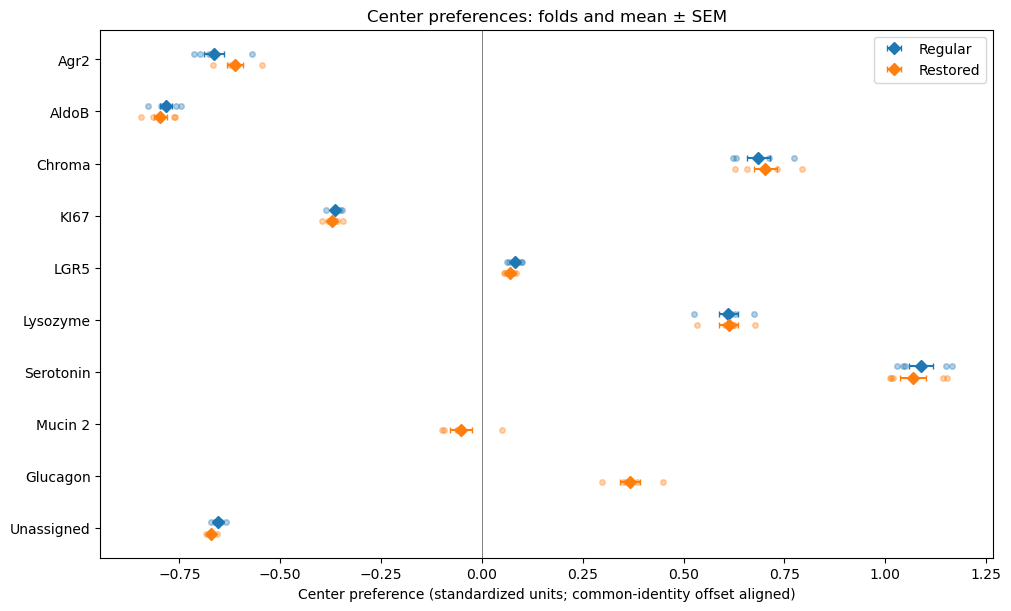

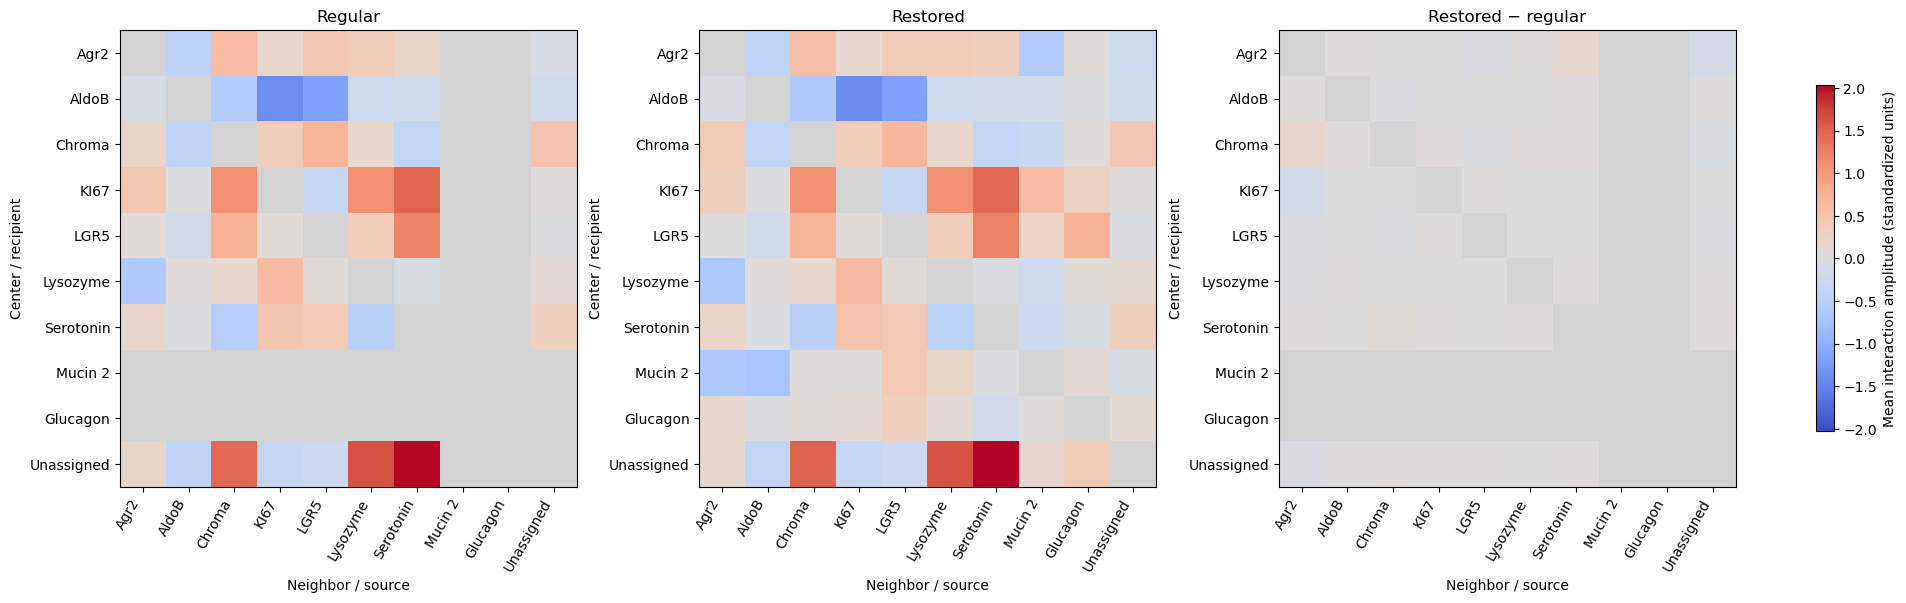

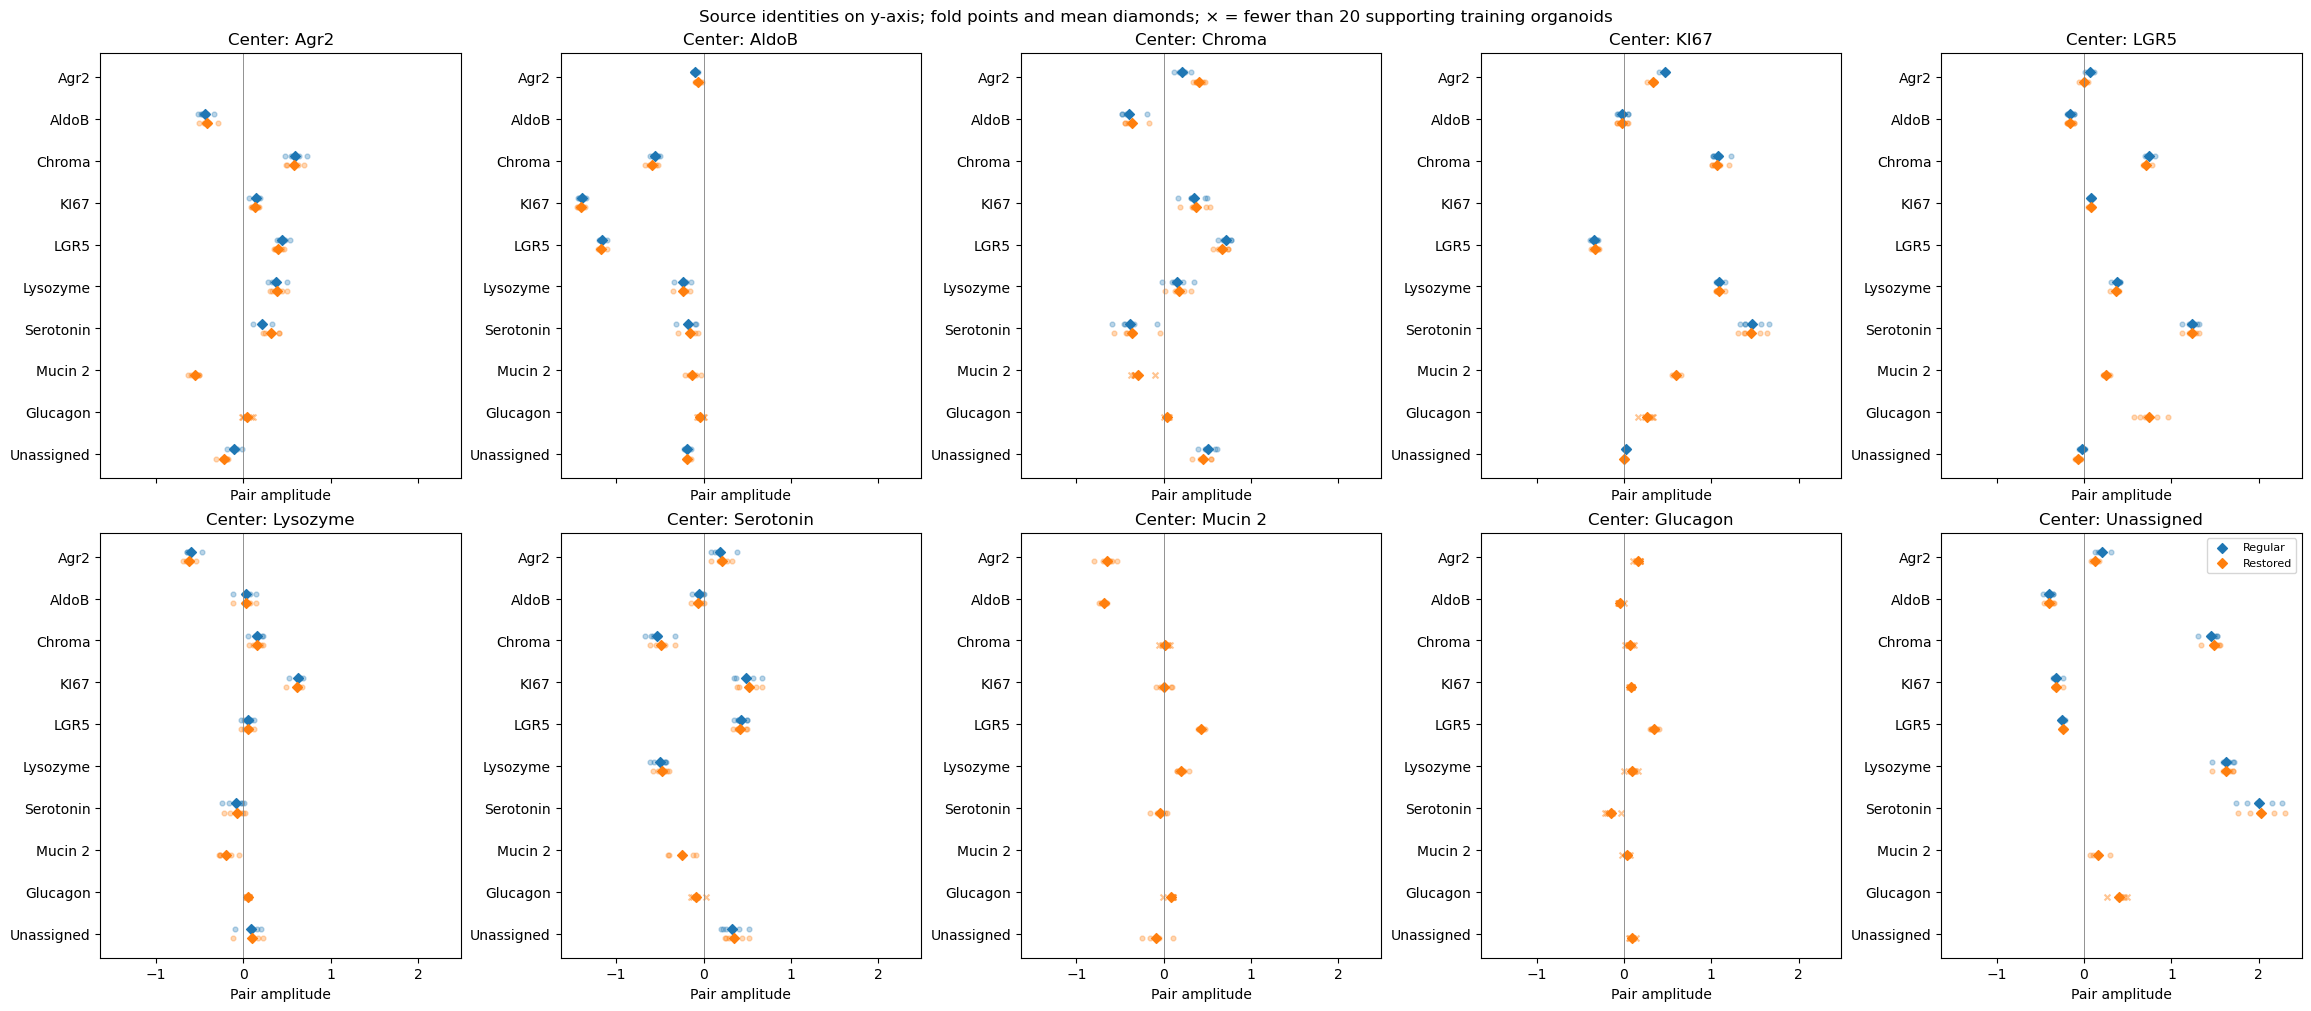

In [7]:
centers=coefficients[coefficients.family=='center'];pairs=coefficients[coefficients.family=='interaction']
fig,ax=plt.subplots(figsize=(10,6),layout='constrained')
for mi,label in enumerate(['Regular','Restored']):
    for i,name in enumerate(identity_names):
        values=centers[(centers.model==label)&(centers.recipient==name)].value
        if values.empty:continue
        y=i+(mi-.5)*.22
        ax.scatter(values,np.full(len(values),y),color=colors[label],alpha=.35,s=16)
        ax.errorbar(values.mean(),y,xerr=values.sem(),fmt='D',color=colors[label],label=label if i==0 else None,capsize=2)
ax.set_yticks(range(len(identity_names)),identity_names);ax.invert_yaxis();ax.axvline(0,color='gray',lw=.7)
ax.set(xlabel='Center preference (standardized units; common-identity offset aligned)',title='Center preferences: folds and mean ± SEM');ax.legend()
save_figure(fig,'03_center_coefficients')
matrices={label:pairs[pairs.model==label].groupby(['recipient','source']).value.mean().unstack().reindex(index=identity_names,columns=identity_names) for label in ['Regular','Restored']}
limit=max(float(np.nanmax(abs(m.to_numpy()))) for m in matrices.values())
fig,axes=plt.subplots(1,3,figsize=(19,6),layout='constrained');cmap=plt.get_cmap('coolwarm').copy();cmap.set_bad('lightgray')
for ax,title,matrix in zip(axes,['Regular','Restored','Restored − regular'],[matrices['Regular'],matrices['Restored'],matrices['Restored']-matrices['Regular']]):
    im=ax.imshow(matrix.to_numpy(),cmap=cmap,vmin=-limit,vmax=limit)
    ax.set_xticks(range(len(identity_names)),identity_names,rotation=60,ha='right');ax.set_yticks(range(len(identity_names)),identity_names)
    ax.set(title=title,xlabel='Neighbor / source',ylabel='Center / recipient')
fig.colorbar(im,ax=axes,label='Mean interaction amplitude (standardized units)',shrink=.7)
save_figure(fig,'04_pair_heatmaps')
fig,axes=plt.subplots(2,5,figsize=(23,10),sharex=True,sharey=True,layout='constrained')
for ax,A in zip(axes.flat,identity_names):
    for mi,label in enumerate(['Regular','Restored']):
        for j,B in enumerate(identity_names):
            group=pairs[(pairs.model==label)&(pairs.recipient==A)&(pairs.source==B)]
            values=group.value
            if values.empty:continue
            y=j+(mi-.5)*.22
            for weak,part in group.groupby(group.support<SETTINGS['min_pair_organoids']):
                ax.scatter(part.value,np.full(len(part),y),s=18 if weak else 12,marker='x' if weak else 'o',alpha=.45 if weak else .3,color=colors[label])
            ax.scatter(values.mean(),y,s=25,marker='D',color=colors[label],label=label if B==next(b for b in identity_names if b!=A) else None)
    ax.axvline(0,color='gray',lw=.6);ax.set(title=f'Center: {A}',xlabel='Pair amplitude')
    ax.set_yticks(range(len(identity_names)),identity_names);ax.tick_params(labelleft=True)
axes.flat[0].invert_yaxis();axes.flat[-1].legend(fontsize=8)
fig.suptitle('Source identities on y-axis; fold points and mean diamonds; × = fewer than 20 supporting training organoids')
save_figure(fig,'05_pair_fold_comparison')
stability=pairs.groupby(['model','recipient','source']).agg(mean=('value','mean'),sd=('value','std'),minimum=('value','min'),maximum=('value','max'),min_support=('support','min'))
stability['same_sign']=(stability.minimum>0)|(stability.maximum<0)
stability.to_csv(OUTPUT_DIR/'interaction_stability.csv')
centers.groupby(['model','recipient']).value.agg(['mean','std','min','max']).to_csv(OUTPUT_DIR/'center_stability.csv')


## Findings: restored_mucin_glucagon_gamma05_20261005_154027

Restoring Mucin 2/Glucagon and refitting the five matched folds leaves prediction accuracy nearly unchanged: physical validation MSE **0.00396009 → 0.00395497** (−0.13%), standardized MSE **0.812012 → 0.810945**. The small physical improvement has the same sign in all five folds. It is concentrated in the stained experiment; the unstained experiment becomes slightly worse. This is not a substantial predictive gain.

The useful change is in the attribution of the fitted local preference. For **LGR5 recipients**, the Agr2 source amplitude changes **+0.069 → approximately 0**, while the newly distinguished Mucin 2 source has amplitude **+0.248**, positive in every fold (minimum training support 270 organoids). For **KI67 recipients**, Agr2 changes **+0.466 → +0.331**, while Mucin 2 has amplitude **+0.602**, also positive in every fold (minimum support 350 organoids). These are presence coefficients before accommodation, in standardized-curvature units. They suggest that separating Goblet identity resolves part of the previous Agr2-associated signal; they do not prove a signaling mechanism.

Center preferences for most shared identities move only modestly after aligning their arbitrary offset. Newly fitted Mucin 2 and Glucagon center preferences are −0.053 and +0.367 in that convention; the former crosses zero across folds. These zero-relative values are not absolute native-cell curvatures.

There are now **90 directed pair amplitudes** instead of 56. Signs agree across all folds for 73/90 (previously 48/56), but 18 restored-model pairs have fewer than 20 supporting training organoids in at least one fold. Most involve Glucagon, with two involving Mucin 2/Chroma. Crosses in the fold-coefficient figure flag these cases. Fold overlap and absence of both channels from the second experiment limit biological generalization, even where signs agree. The full support and stability tables are saved beside the figures.

## Save the comparison and reusable model artifacts
The run contains model bundles, restored fold data, exact splits, target moments, settings and prediction archives. Save source snapshots and a compact numerical summary. All dataset changes are confined to the new export directory; the regular dataset and reference checkpoints remain intact.

In [4]:
# Standard per-organoid training summaries for other analysis notebooks.
selection=(metrics.region=='total')|((metrics.cohort=='spherical')&(metrics.region=='spherical_or_no_detected_crypt'))
validation=metrics[selection&(metrics.model=='Restored')].copy()
means=metrics[selection&(metrics.model=='Measured mean')][['fold','cohort','organoid_str','mse']].rename(columns={'mse':'mean_baseline_mse'})
validation=validation.merge(means,on=['fold','cohort','organoid_str'],validate='one_to_one')
by_fold={r['fold']:r for r in records}
for column in ['key','variant','target_mode','gamma']:
    validation[column]=validation.fold.map(lambda f:by_fold[f][column])
validation.to_csv(RUN_DIR/'validation_mse.csv',index=False)
pd.DataFrame(records)[['fold','target_mode','variant','key','gamma','inner_mse']].to_csv(RUN_DIR/'selected_models.csv',index=False)

total=fold_scores[fold_scores.region=='total'].groupby('model')[['mse','standardized_mse']].mean()
change=100*(total.loc['Restored']/total.loc['Regular']-1)
print('Ordinary validation mean MSE:');display(total)
print('Restored versus regular MSE change (%):',change.to_dict())
report=dict(physical_mse=total.mse.to_dict(),standardized_mse=total.standardized_mse.to_dict(),percent_change=change.to_dict(),
    restored_dataset=str(DATASET_DIR),reference_run=str(REFERENCE_DIR),models=len(records),folds=len(membership),
    conditional_mean_sd=True,missing_marker_identities_not_imputed=True)
(OUTPUT_DIR/'findings.json').write_text(json.dumps(report,indent=2))
(RUN_DIR/'complete.json').write_text(json.dumps(dict(models=len(records),folds=len(membership),conditional_moments=True),indent=2))
(OUTPUT_DIR/'complete.json').write_text(json.dumps(dict(figures=sorted(p.name for p in OUTPUT_DIR.glob('*.png')),models=len(records)),indent=2))
for filename in [f'experiments/training/{NOTEBOOK_NAME}.ipynb','src/data/marker_restoration.py','src/data/marker_exclusivity.py','src/models/curvature_energy.py','src/training/energy_fit.py']:
    target=RUN_DIR/'source_snapshot'/filename;target.parent.mkdir(parents=True,exist_ok=True);shutil.copy2(PROJECT_ROOT/filename,target)
print('Completed run:',RUN_DIR)


Ordinary validation mean MSE:


,mse,standardized_mse
model,,
Measured mean,0.005131,1.000000
Regular,0.003960,0.812012
Restored,0.003955,0.810945


Restored versus regular MSE change (%): {'mse': -0.12933931440658464, 'standardized_mse': -0.13144401011656592}
Completed run: training_results/restored_fate_energy_comparison/restored_mucin_glucagon_gamma05_20261005_154027
